<a href="https://colab.research.google.com/github/ydv-prince/EDA/blob/main/4_EDA_Travel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [23]:
df = pd.read_csv('Travel.csv')

In [24]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [25]:
df.shape

(4888, 20)

In [26]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [28]:
df.Gender.unique()

array(['Female', 'Male', 'Fe Male'], dtype=object)

In [29]:
df['Gender'].replace('Fe Male', 'Female', inplace = True)

In [30]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [32]:
df.isnull().sum().sort_values(ascending=False)

,0
DurationOfPitch,251
MonthlyIncome,233
Age,226
NumberOfTrips,140
NumberOfChildrenVisiting,66
NumberOfFollowups,45
PreferredPropertyStar,26
TypeofContact,25
CustomerID,0
ProdTaken,0


In [33]:
df['Age'].unique()

array([41., 49., 37., 33., nan, 32., 59., 30., 38., 36., 35., 31., 34.,
       28., 29., 22., 53., 21., 42., 44., 46., 39., 24., 43., 50., 27.,
       26., 48., 55., 45., 56., 23., 51., 40., 54., 58., 20., 25., 19.,
       57., 52., 47., 18., 60., 61.])

In [37]:
round((df.isnull().sum()/ len(df.index)*100), 2)

,0
CustomerID,0.00
ProdTaken,0.00
Age,4.62
TypeofContact,0.51
CityTier,0.00
DurationOfPitch,5.14
Occupation,0.00
Gender,0.00
NumberOfPersonVisiting,0.00
NumberOfFollowups,0.92


In [39]:
df.dropna(axis = 0, inplace = True)

In [40]:
df.shape

(4128, 20)

In [41]:
cats = ['ProdTaken', 'CityTier', 'PreferredPropertyStar', 'Passport',
        'OwnCar', 'PitchSatisfactionScore', 'TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
        'MaritalStatus', 'Designation']

nums = ['CustomerID', 'Age', 'DurationOfPitch',
       'NumberOfPersonVisiting', 'NumberOfFollowups',
       'NumberOfTrips',
       'NumberOfChildrenVisiting', 'MonthlyIncome']

In [42]:
cats

['ProdTaken',
 'CityTier',
 'PreferredPropertyStar',
 'Passport',
 'OwnCar',
 'PitchSatisfactionScore',
 'TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [43]:
nums

['CustomerID',
 'Age',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'NumberOfTrips',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [44]:
df[cats]

,ProdTaken,CityTier,PreferredPropertyStar,Passport,OwnCar,PitchSatisfactionScore,TypeofContact,Occupation,Gender,ProductPitched,MaritalStatus,Designation
0,1,3,3.0,1,1,2,Self Enquiry,Salaried,Female,Deluxe,Single,Manager
1,0,1,4.0,0,1,3,Company Invited,Salaried,Male,Deluxe,Divorced,Manager
2,1,1,3.0,1,0,3,Self Enquiry,Free Lancer,Male,Basic,Single,Executive
3,0,1,3.0,1,1,5,Company Invited,Salaried,Female,Basic,Divorced,Executive
5,0,1,3.0,0,1,5,Company Invited,Salaried,Male,Basic,Single,Executive
...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,3,4.0,1,1,1,Self Enquiry,Small Business,Male,Deluxe,Unmarried,Manager
4884,1,1,3.0,1,1,3,Company Invited,Salaried,Male,Basic,Single,Executive
4885,1,3,4.0,0,1,1,Self Enquiry,Salaried,Female,Standard,Married,Senior Manager
4886,1,3,3.0,0,0,5,Self Enquiry,Small Business,Male,Basic,Single,Executive


In [45]:
df[nums]

,CustomerID,Age,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
0,200000,41.0,6.0,3,3.0,1.0,0.0,20993.0
1,200001,49.0,14.0,3,4.0,2.0,2.0,20130.0
2,200002,37.0,8.0,3,4.0,7.0,0.0,17090.0
3,200003,33.0,9.0,2,3.0,2.0,1.0,17909.0
5,200005,32.0,8.0,3,3.0,1.0,1.0,18068.0
...,...,...,...,...,...,...,...,...
4883,204883,49.0,9.0,3,5.0,2.0,1.0,26576.0
4884,204884,28.0,31.0,4,5.0,3.0,2.0,21212.0
4885,204885,52.0,17.0,4,4.0,7.0,3.0,31820.0
4886,204886,19.0,16.0,3,4.0,3.0,2.0,20289.0


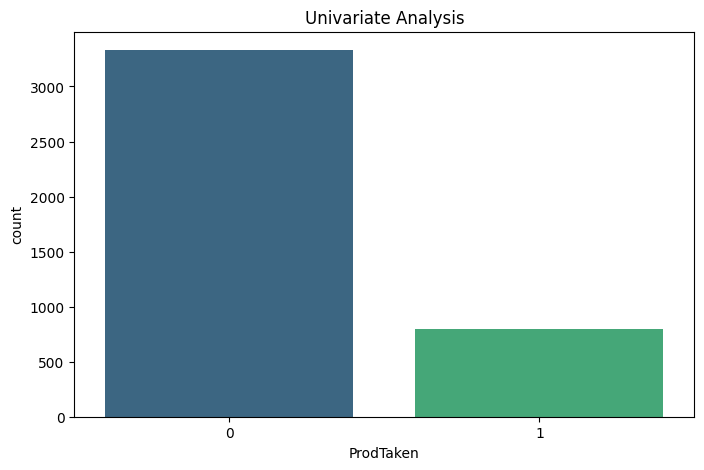

In [48]:
#Univariate analysis for categorical column

plt.figure(figsize = (8,5))
sns.countplot(x = 'ProdTaken', data = df, palette = 'viridis')
plt.title('Univariate Analysis')
plt.show()

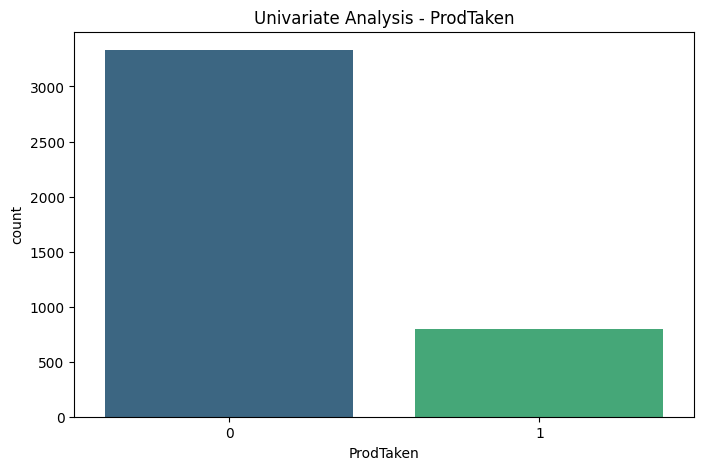

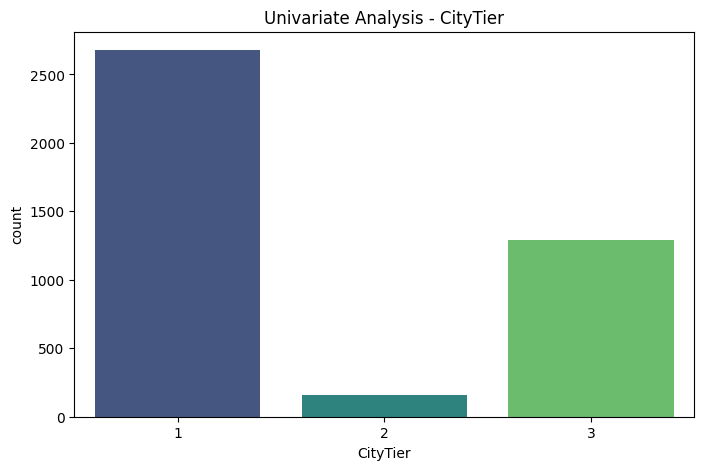

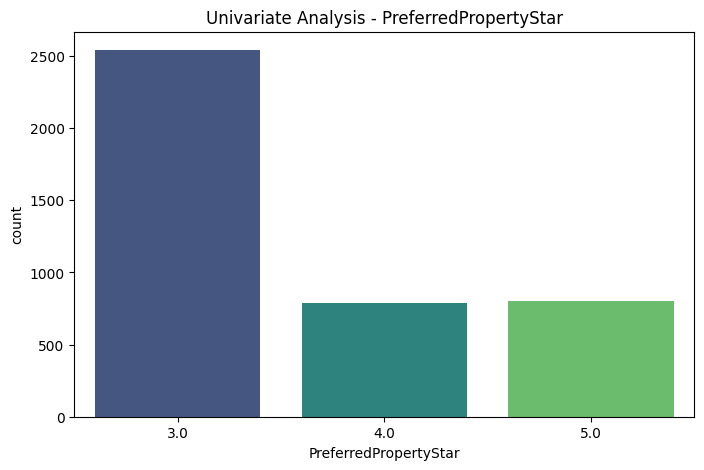

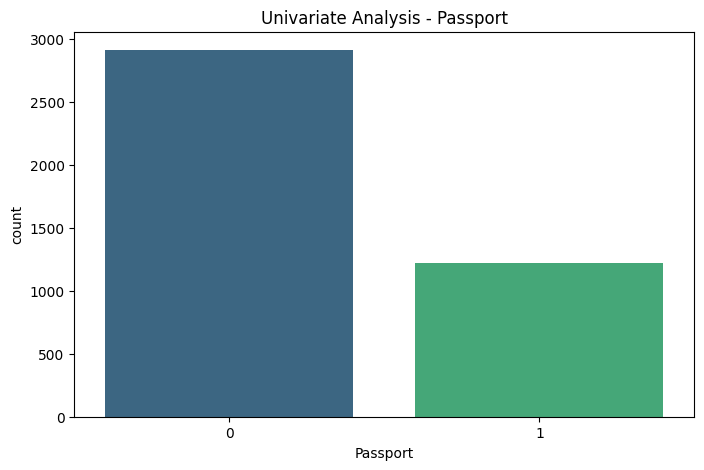

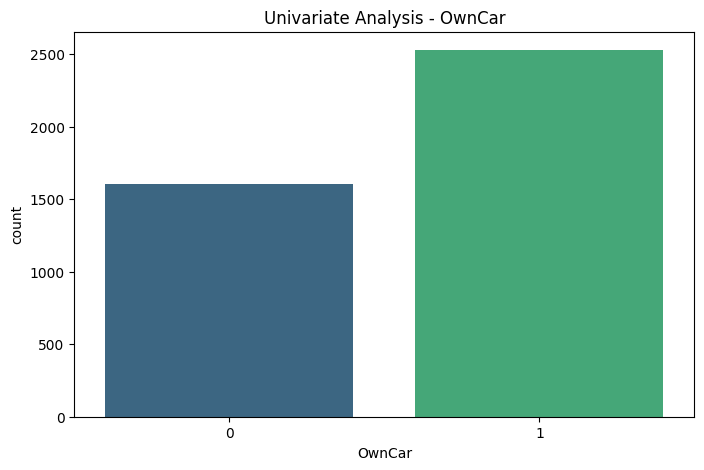

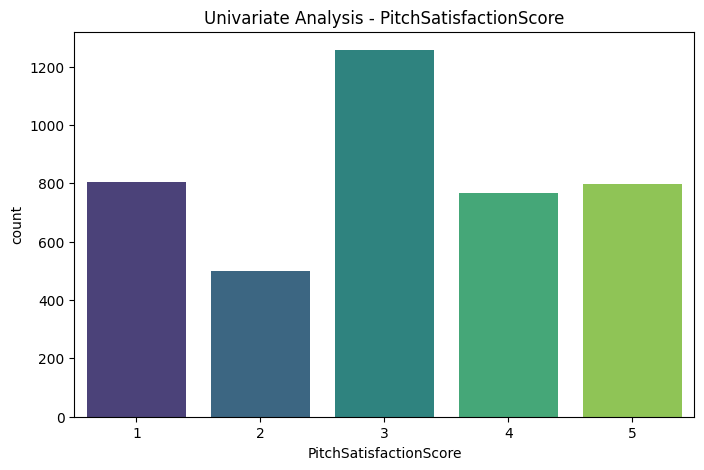

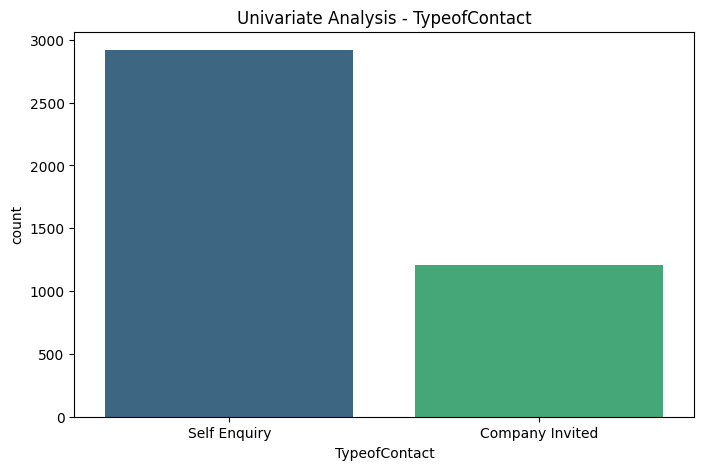

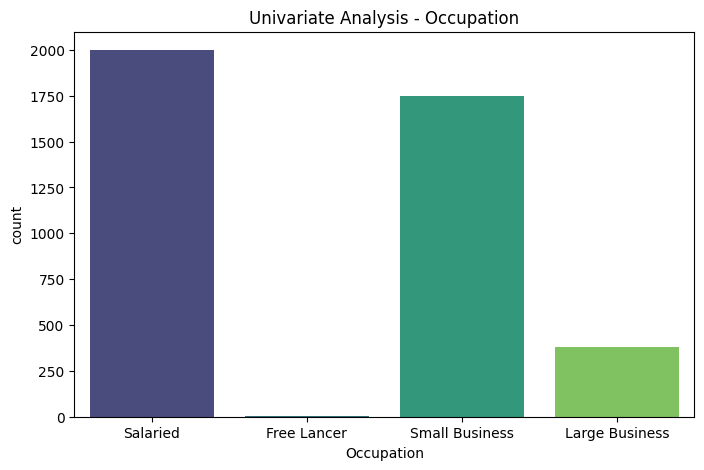

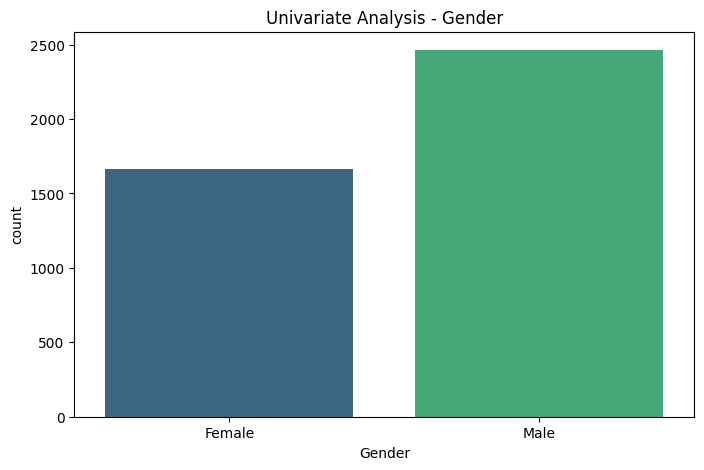

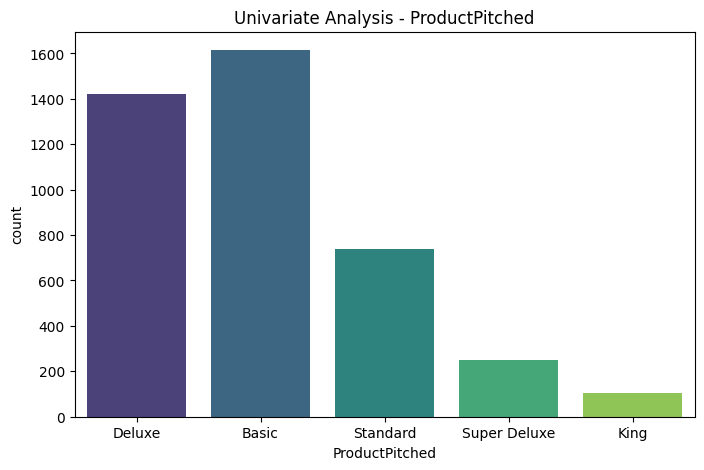

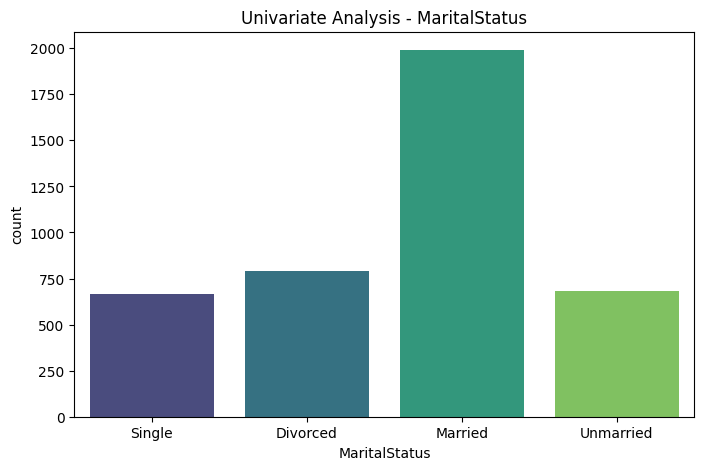

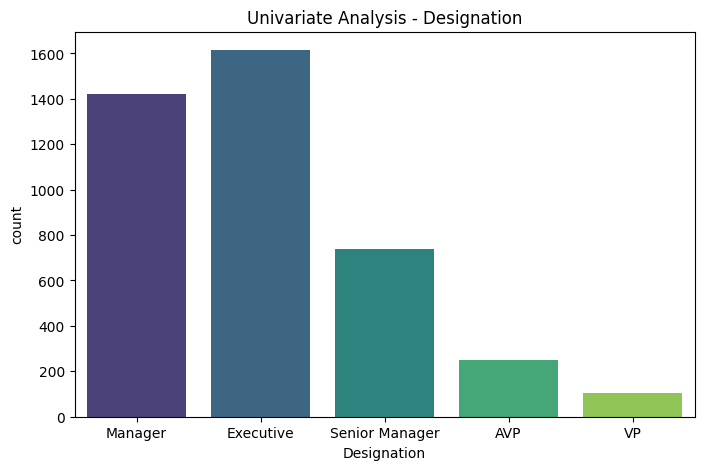

In [50]:
for cat in cats:
  plt.figure(figsize = (8,5))
  sns.countplot(x = cat, data = df, palette = 'viridis')
  plt.title(f"Univariate Analysis - {cat}")
  plt.show()

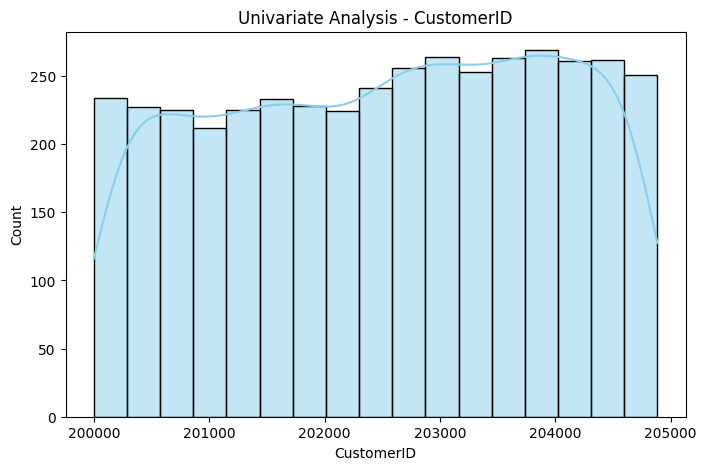

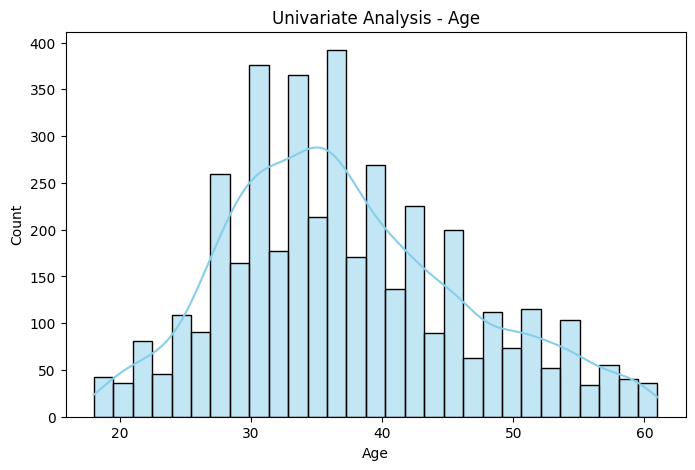

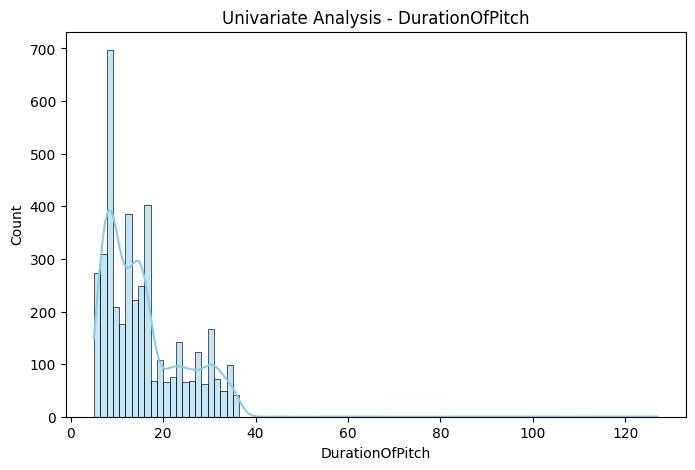

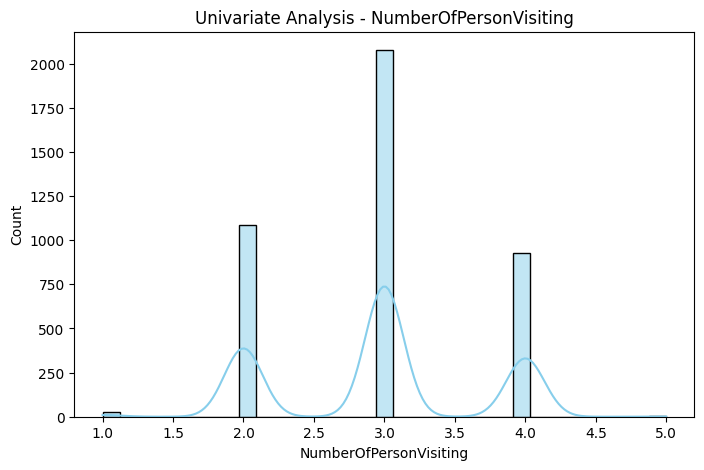

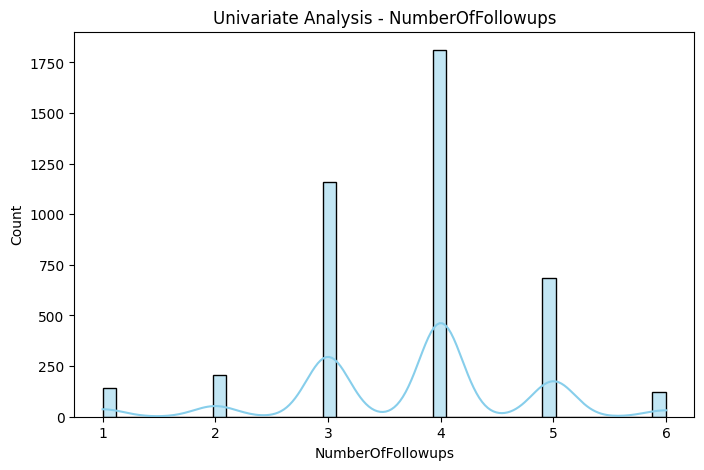

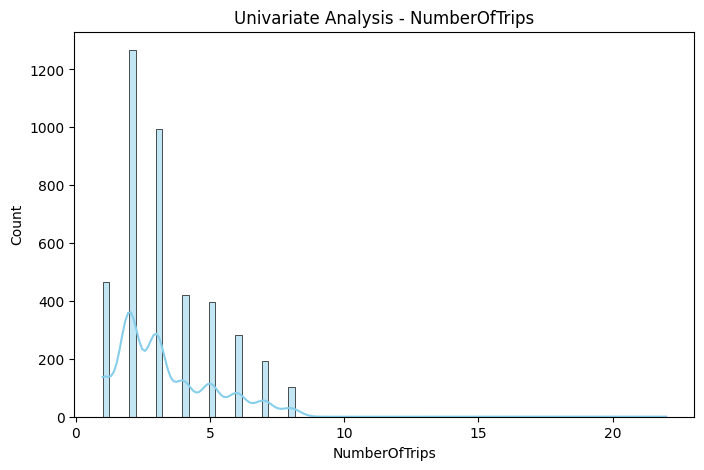

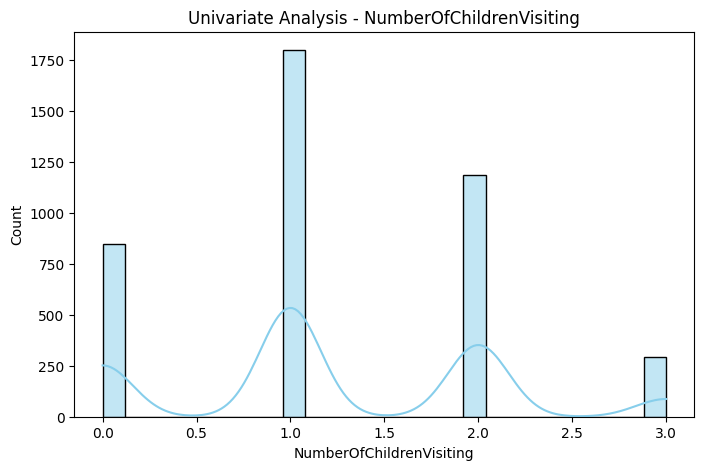

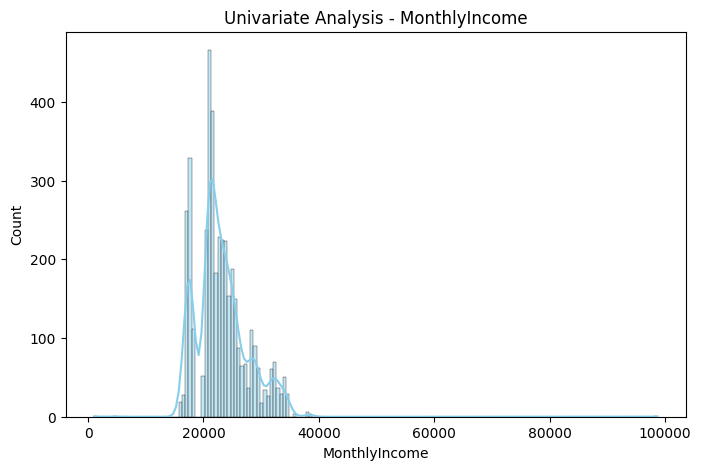

In [52]:
#Univariate Analysis of numerical columns

for num in nums:
  plt.figure(figsize = (8,5))
  sns.histplot(df[num], kde = True, color = 'skyblue')
  plt.title(f"Univariate Analysis - {num}")
  plt.show()

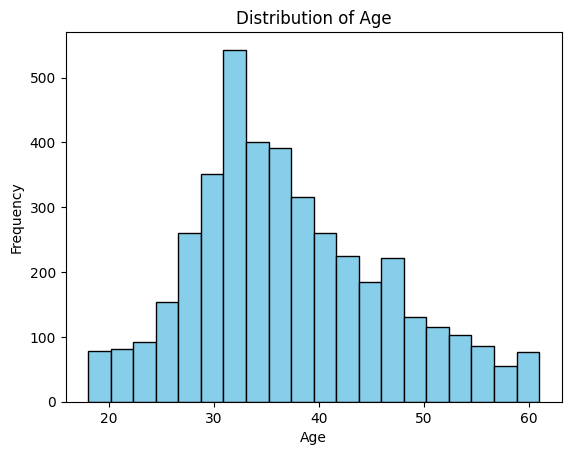

In [57]:
plt.hist(df['Age'].dropna(), bins = 20, color = 'skyblue', edgecolor = 'black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [58]:
#Insights >> 30 - 40 age group is travelling more

In [59]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [61]:
df['TypeofContact'].unique()

array(['Self Enquiry', 'Company Invited'], dtype=object)

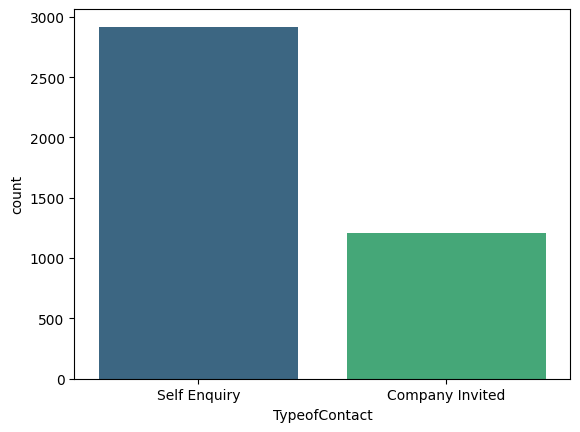

In [63]:
sns.countplot(x = 'TypeofContact', data = df, palette = 'viridis')
plt.show()

In [64]:
#Insights >> Self Enquiry is more in the TypeofContact

In [66]:
cats

['ProdTaken',
 'CityTier',
 'PreferredPropertyStar',
 'Passport',
 'OwnCar',
 'PitchSatisfactionScore',
 'TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [69]:
df['CityTier'].unique()
#CityTier is numerical and if you do df.describe() >> mean, median, mode

array([3, 1, 2])

In [71]:
df.describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.0000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000
mean,202527.763808,0.193072,37.231831,1.663275,15.584787,2.949370,3.741521,3.578488,3.2953,0.295300,3.060804,0.612161,1.223595,23178.464147
std,1409.439133,0.394757,9.174521,0.920640,8.398142,0.718818,1.006786,0.795031,1.8563,0.456233,1.363064,0.487317,0.852685,4506.614622
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.0000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,201320.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.0000,0.000000,2.000000,0.000000,1.000000,20751.000000
50%,202603.500000,0.000000,36.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.0000,0.000000,3.000000,1.000000,1.000000,22418.000000
75%,203748.250000,0.000000,43.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.0000,1.000000,4.000000,1.000000,2.000000,25301.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.0000,1.000000,5.000000,1.000000,3.000000,98678.000000


In [72]:
#Average of 1.66 for CityTier doesn't make any sense

In [73]:
df[nums].describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4128.0,202527.763808,1409.439133,200000.0,201320.75,202603.5,203748.25,204887.0
Age,4128.0,37.231831,9.174521,18.0,31.00,36.0,43.00,61.0
DurationOfPitch,4128.0,15.584787,8.398142,5.0,9.00,14.0,20.00,127.0
NumberOfPersonVisiting,4128.0,2.949370,0.718818,1.0,2.00,3.0,3.00,5.0
NumberOfFollowups,4128.0,3.741521,1.006786,1.0,3.00,4.0,4.00,6.0
NumberOfTrips,4128.0,3.295300,1.856300,1.0,2.00,3.0,4.00,22.0
NumberOfChildrenVisiting,4128.0,1.223595,0.852685,0.0,1.00,1.0,2.00,3.0
MonthlyIncome,4128.0,23178.464147,4506.614622,1000.0,20751.00,22418.0,25301.00,98678.0


In [75]:
df[cats]

,ProdTaken,CityTier,PreferredPropertyStar,Passport,OwnCar,PitchSatisfactionScore,TypeofContact,Occupation,Gender,ProductPitched,MaritalStatus,Designation
0,1,3,3.0,1,1,2,Self Enquiry,Salaried,Female,Deluxe,Single,Manager
1,0,1,4.0,0,1,3,Company Invited,Salaried,Male,Deluxe,Divorced,Manager
2,1,1,3.0,1,0,3,Self Enquiry,Free Lancer,Male,Basic,Single,Executive
3,0,1,3.0,1,1,5,Company Invited,Salaried,Female,Basic,Divorced,Executive
5,0,1,3.0,0,1,5,Company Invited,Salaried,Male,Basic,Single,Executive
...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,3,4.0,1,1,1,Self Enquiry,Small Business,Male,Deluxe,Unmarried,Manager
4884,1,1,3.0,1,1,3,Company Invited,Salaried,Male,Basic,Single,Executive
4885,1,3,4.0,0,1,1,Self Enquiry,Salaried,Female,Standard,Married,Senior Manager
4886,1,3,3.0,0,0,5,Self Enquiry,Small Business,Male,Basic,Single,Executive


In [76]:
df[cats].describe().T

,count,mean,std,min,25%,50%,75%,max
ProdTaken,4128.0,0.193072,0.394757,0.0,0.0,0.0,0.0,1.0
CityTier,4128.0,1.663275,0.920640,1.0,1.0,1.0,3.0,3.0
PreferredPropertyStar,4128.0,3.578488,0.795031,3.0,3.0,3.0,4.0,5.0
Passport,4128.0,0.295300,0.456233,0.0,0.0,0.0,1.0,1.0
OwnCar,4128.0,0.612161,0.487317,0.0,0.0,1.0,1.0,1.0
PitchSatisfactionScore,4128.0,3.060804,1.363064,1.0,2.0,3.0,4.0,5.0


In [78]:
#All of the column above is discrete but in terms of business mean values of above columns doesn't makes any sense
#So these columns are to be treated as a categorical columns
#To trust these columns as categorical columns, we will convert them to object

In [79]:
df[cats] = df[cats].astype('object')

In [81]:
df[cats].describe().T

,count,unique,top,freq
ProdTaken,4128,2,0,3331
CityTier,4128,3,1,2678
PreferredPropertyStar,4128.0,3.0,3.0,2541.0
Passport,4128,2,0,2909
OwnCar,4128,2,1,2527
PitchSatisfactionScore,4128,5,3,1257
TypeofContact,4128,2,Self Enquiry,2918
Occupation,4128,4,Salaried,1999
Gender,4128,2,Male,2463
ProductPitched,4128,5,Basic,1615


In [83]:
#To make sure these columns are treated as categorical earlier we had made bifurcation categorical manually

In [84]:
for i in df[cats].columns:
  x = df[i].unique()
  print(f"{i}: {x}")
  print()

ProdTaken: [1 0]

CityTier: [3 1 2]

PreferredPropertyStar: [3.0 4.0 5.0]

Passport: [1 0]

OwnCar: [1 0]

PitchSatisfactionScore: [2 3 5 4 1]

TypeofContact: ['Self Enquiry' 'Company Invited']

Occupation: ['Salaried' 'Free Lancer' 'Small Business' 'Large Business']

Gender: ['Female' 'Male']

ProductPitched: ['Deluxe' 'Basic' 'Standard' 'Super Deluxe' 'King']

MaritalStatus: ['Single' 'Divorced' 'Married' 'Unmarried']

Designation: ['Manager' 'Executive' 'Senior Manager' 'AVP' 'VP']



In [85]:
#Bi-Variate Analysis

In [86]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

<Axes: xlabel='Age', ylabel='DurationOfPitch'>

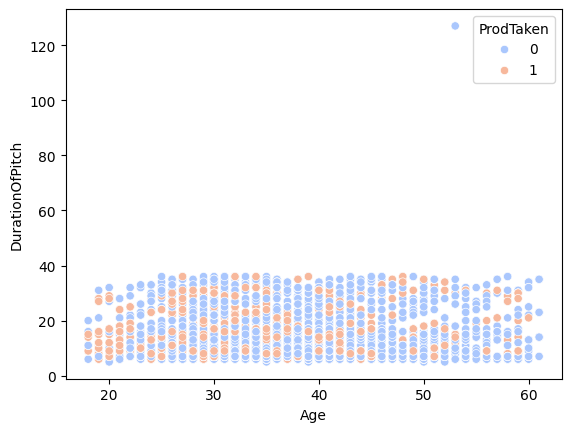

In [87]:
sns.scatterplot(x = 'Age', y = 'DurationOfPitch', data = df, hue = 'ProdTaken', palette = 'coolwarm')

In [89]:
#Stacked bar chart b/w martial status and product taken
crosstab = pd.crosstab(df['MaritalStatus'], df['ProdTaken'], normalize= 'index') #normalize gives percentage

In [90]:
crosstab

ProdTaken,0,1
MaritalStatus,,
Divorced,0.866920,0.133080
Married,0.857789,0.142211
Single,0.635682,0.364318
Unmarried,0.756598,0.243402


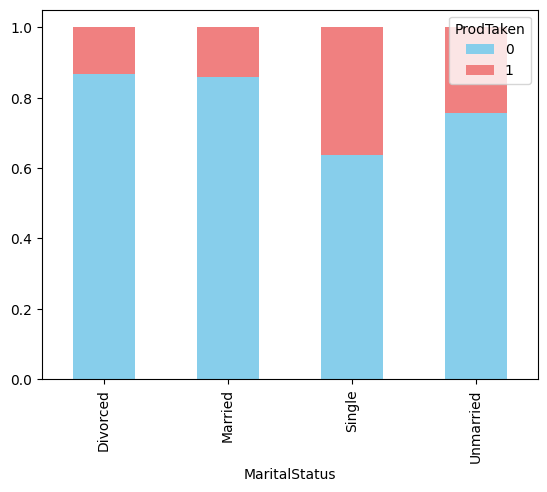

In [93]:
crosstab.plot(kind = 'bar', stacked = True, color = ['skyblue', 'lightcoral'])
plt.show()

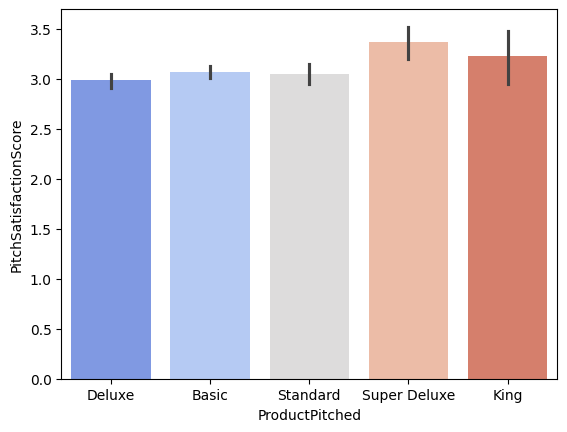

In [95]:
sns.barplot(x = 'ProductPitched', y = 'PitchSatisfactionScore', data = df, palette = 'coolwarm')
plt.show()

In [96]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

<Axes: xlabel='NumberOfFollowups', ylabel='PitchSatisfactionScore'>

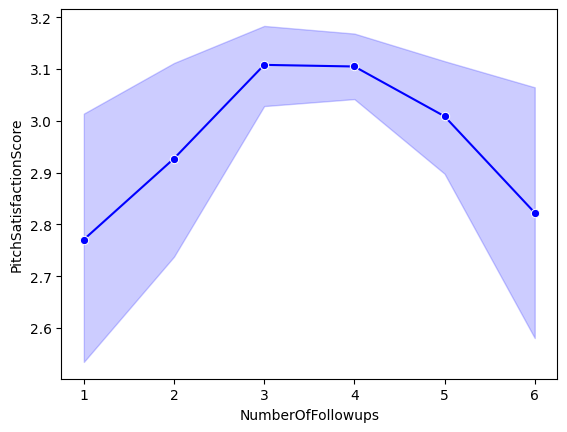

In [102]:
sns.lineplot(x = 'NumberOfFollowups', y= 'PitchSatisfactionScore', data = df, marker = 'o', color = 'blue')

In [104]:
#Multi-Variate Analysis

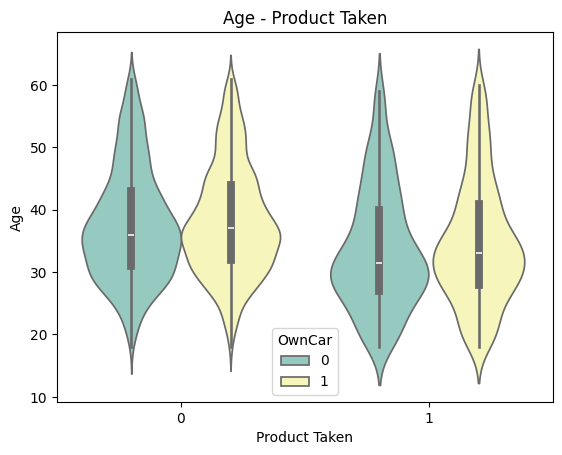

In [110]:
sns.violinplot(x = 'ProdTaken', y = 'Age', data = df, hue = 'OwnCar',  palette = 'Set3')
plt.title('Age - Product Taken')
plt.xlabel('Product Taken')
plt.ylabel('Age')
plt.show()

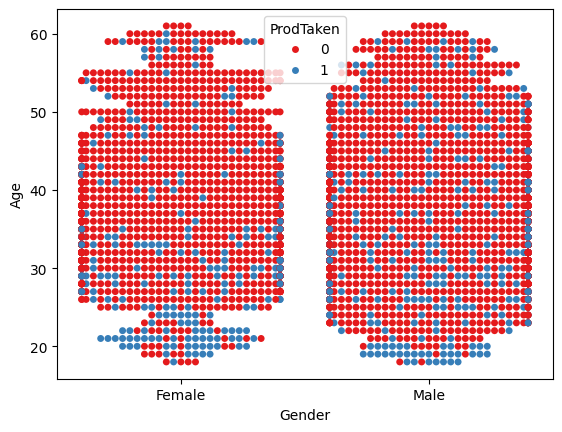

In [111]:
sns.swarmplot(x = 'Gender', y = 'Age', data = df, hue = 'ProdTaken', palette = 'Set1')
plt.show()

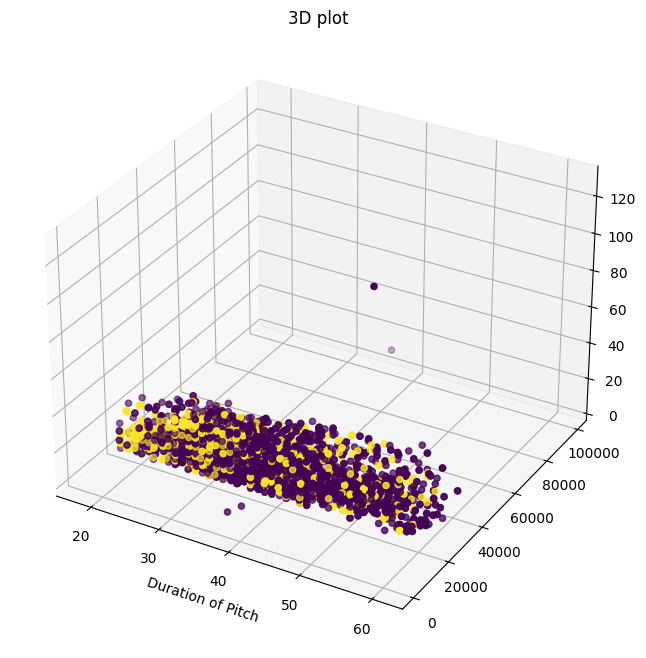

In [114]:
#3D-plots
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(df['Age'], df['MonthlyIncome'], df['DurationOfPitch'], c = df['ProdTaken'], cmap = 'viridis')
ax.set_xlabel('Age')
ax.set_xlabel('Monthly Income')
ax.set_xlabel('Duration of Pitch')
ax.set_title('3D plot')
plt.show()

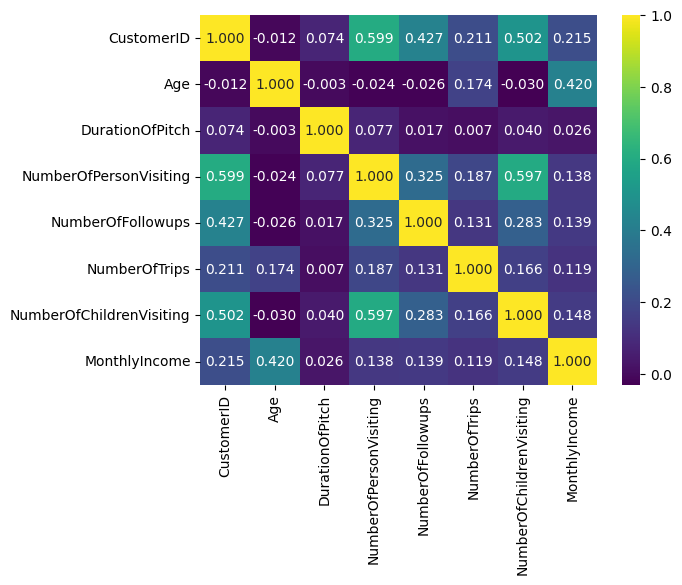

In [116]:
numeric_cols = df.select_dtypes(include = 'number')
sns.heatmap(numeric_cols.corr(), cmap = 'viridis', annot = True, fmt = '.3f')
plt.show()